**ESTUDIANTE**: Miguel Angel Camargo mora

# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [ ]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [ ]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


##parte 1

In [ ]:
import statsmodels.api as sm

# Define the dependent variable (Y) and independent variables (X)
Y = df['nota']
X = df[['horas', 'asistencia', 'promedio']]

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(Y, X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        16:24:45   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0



*   “Si horas aumenta en **1 unidad**, la **nota esperada** aumenta en **0.0412** puntos, **manteniendo constantes** los demás predictores del modelo.”

*   “Si asistencia aumenta en **1 unidad**, la **nota esperada** aumenta en **0.0106** puntos, **manteniendo constantes** los demás predictores del modelo.”

*   “Si promedio aumenta en **1 unidad**, la **nota esperada** aumenta en **0.5753** puntos, **manteniendo constantes** los demás predictores del modelo.”




“Si horas aumenta en **5 unidades**, la **nota esperada** aumenta en **0.0412 (5) = 0.206** puntos, **manteniendo constantes** los demás predictores del modelo.”

## Parte 2



*   Horas:

    - hipotesis
       - H0: Beta(horas) = 0
       - H1: Beta(horas) ≠ 0

    - p-valor < 0.05. Se rechaza H0
    - IC 95%:  [0.024, 0.059], no incluye al cero

   - Cierra con 1 frase: Hay evidencia estadistica suficiente para rechazar la hipotesis nula de que el coeficiente de horas es igual a cero o en otras palabras la idea de que horas no tiene peso en el modelo


*   Asistencia:

    - hipotesis
       - H0: Beta(asistencia) = 0
       - H1: Beta(asistencia) ≠ 0

    - p-valor < 0.05. Se rechaza H0
    - IC 95%: [0.006, 0.015], no incluye al cero


   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: Hay evidencia estadistica suficiente para rechazar la hipotesis nula de que el coeficiente de asistencia es igual a cero o en otras palabras la idea de que asistencia no tiene peso en el modelo


*   Promedio:

    - hipotesis
       - H0: Beta(Promedio) = 0
       - H1: Beta(Promedio) ≠ 0

    - p-valor < 0.05. Se rechaza H0
    - IC 95%: [0.476, 0.674], no incluye al cero

   - Cierra con 1 frase: Hay evidencia estadistica suficiente para rechazar la hipotesis nula de que el coeficiente de Promedio es igual a cero o en otras palabras la idea de que promedio no tiene peso en el modelo


## parte 3

Primeros 5 residuales:
 0    0.0073
1    0.3738
2    0.1859
3    0.3458
4   -0.2403
dtype: float64

Primeros 5 valores ajustados:
 0    3.1880
1    3.1423
2    3.7254
3    3.6773
4    4.3995
dtype: float64


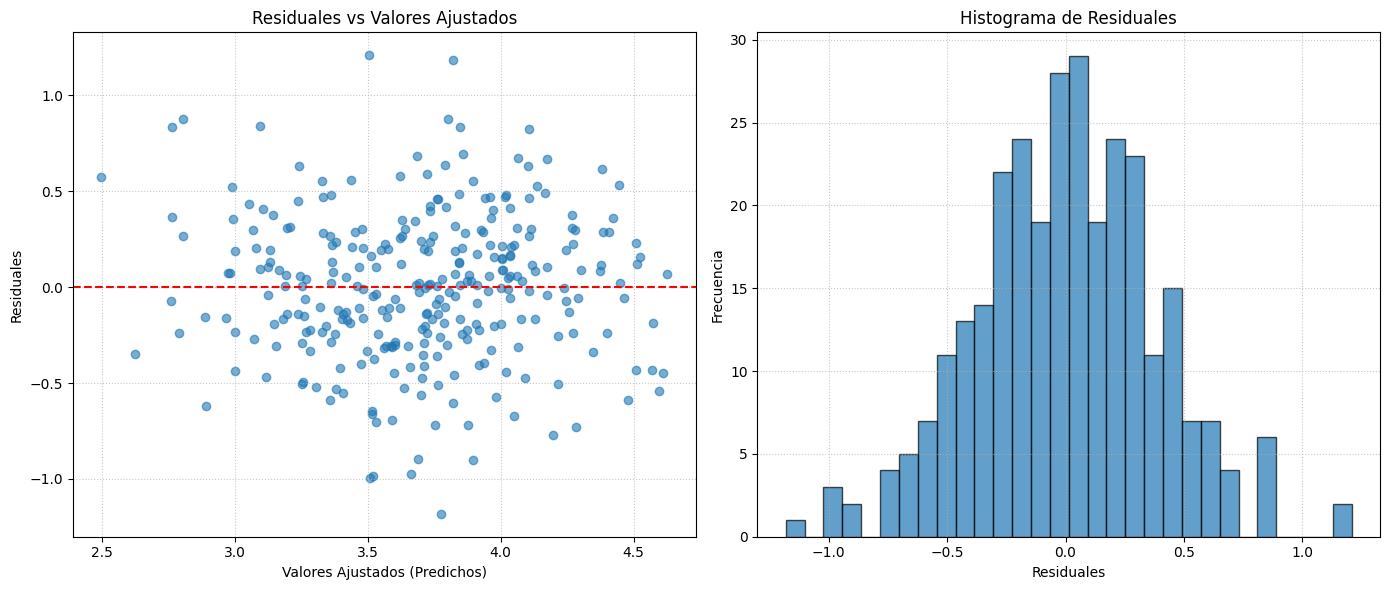

In [ ]:
# 6) Calcula residuales y valores ajustados (predichos)
residuals = results.resid
fitted_values = results.fittedvalues

print("Primeros 5 residuales:\n", residuals.head())
print("\nPrimeros 5 valores ajustados:\n", fitted_values.head())

# 7) Haz estas 2 gráficas:
plt.figure(figsize=(14, 6))

# (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados (Predichos)')
plt.ylabel('Residuales')
plt.title('Residuales vs Valores Ajustados')
plt.grid(True, linestyle=':', alpha=0.7)

# (G2) Histograma de residuales
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuales')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

  - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?

  Se observa una nube algo ancha alrededor de cero  
   - ¿hay outliers evidentes?

   En ambos graficos se pueden observar un par de de datos, ubicados en los extremos tanto inferior como superior, que estan algo alejados del resto, sin embargo viasualmente no se ven lo suficientemente alejados (3 desviaciones estandar de la media) como para decir que son outliers

   - ¿qué supuesto podría fallar si ves abanico?

   Si se observa el abanico, el supuesto de homocedasticidad podria fallar, pues en regresion asumimos que el ruido tiene el mismo tamaño para todos los valores de X


##Parte 4

In [ ]:
#Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.

#9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.

horas10 = df['horas'] / 10
df['horas10'] = horas10


# Define the dependent variable (Y) and independent variables (X)
Y = df['nota']
X = df[['horas10', 'asistencia', 'promedio']]

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(Y, X)
results = model.fit()

# Print the summary of the regression results
print(results.summary())



                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        16:24:45   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
  - ¿por qué cambia el número?

    β̂_horas (M3) = 0.0412
    β̂_horas10 (M3b) = 0.4117

    Cambia porque los datos de horas estan en diferentes unidades y para mantener la proporcion del efecto de notas, el coeficiente se hace mas grande

   
   - ¿cómo cambia la interpretación en palabras?

   La interpretacion cambia porque ahora una unidad equivale a 10 horas originales, por lo que al aumentar una unidad de horas_diez, la nota aumenta 0.4117 puntos, manteniendo las demas variables constantes



##parrafo final


En general se observa que los 3 coeficientes son positivos, por lo que tienen una relacion directamente proporcial con la variable notas, es decir que, si varia una y las otras variables permanecen constantes, un aumento en la variable libre se asocia con un aumento en la nota esperada. Por ejemplo, un aumento de una hora de estudio se asocia con un incremento de 0.0412 puntos en la nota cuando lo demas permanece constante.

Dado que la prueba de hipotesis para los 3 coeficientes fue significativa, quiere decir que cada uno ayuda a explicar en parte la variabilidad de notas y hay evidencia fuerte de que tienen una asociación lineal estadísticamente significativa con la nota.

Graficamente se observo que los residuales no mostraban comportamiento de abanico por lo que es probable que se cumpla el supuesto de homocedasticidad, faltaria hacer pruebas de hipotesis para comprobarlo

al cambiar las unidades, el valor del coeficiente cambia para mantener la proporcion del efecto de la varaible horas sobre notas


